Class distribution after SMOTE:
label
0    67343
1    67343
Name: count, dtype: int64

Random Forest Results:
Accuracy : 0.7743
Precision: 0.9682
Recall   : 0.6240
F1 Score : 0.7589

Logistic Regression Results:
Accuracy : 0.7483
Precision: 0.9146
Recall   : 0.6152
F1 Score : 0.7356


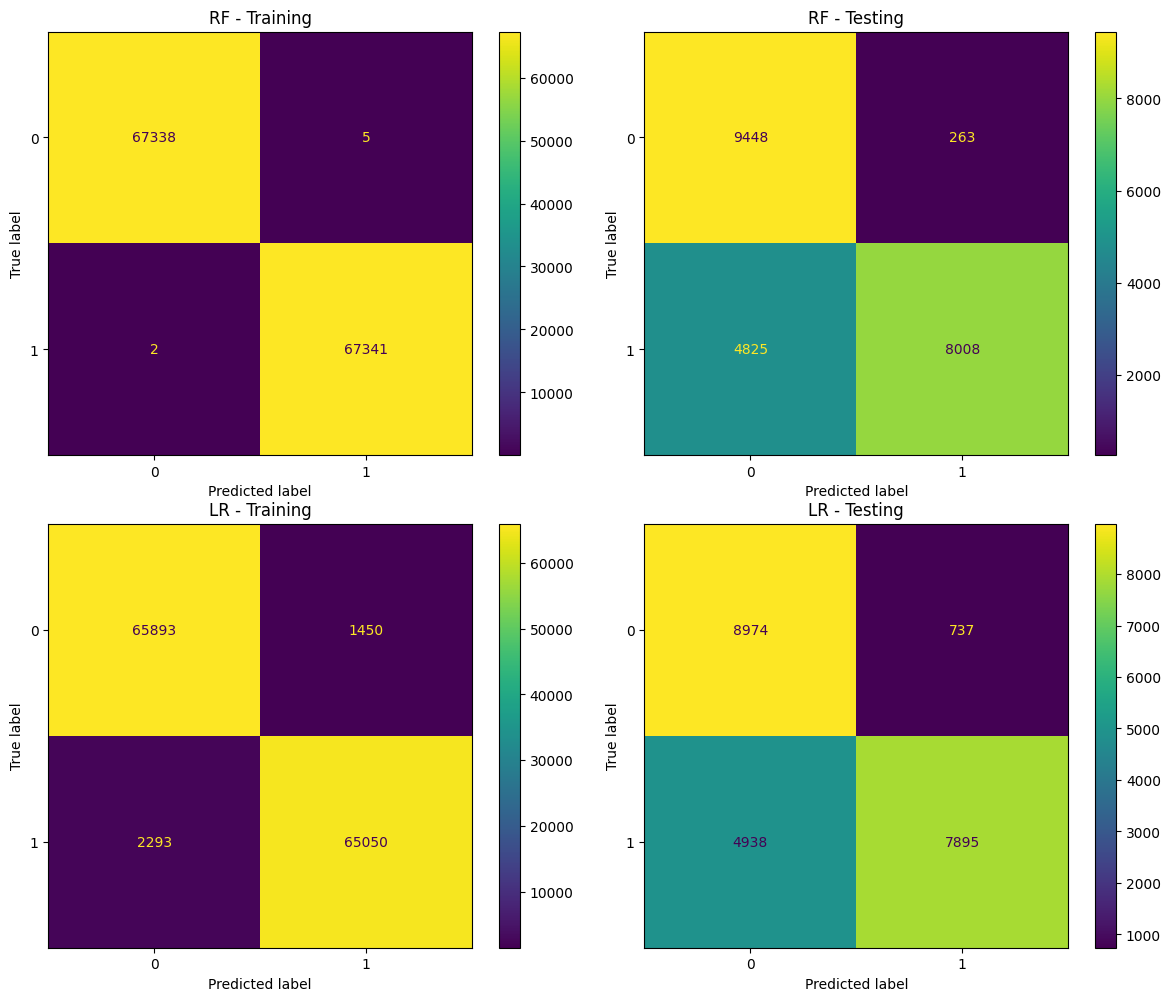

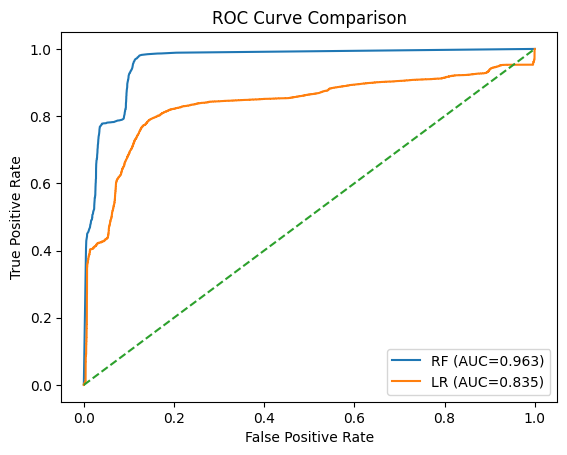

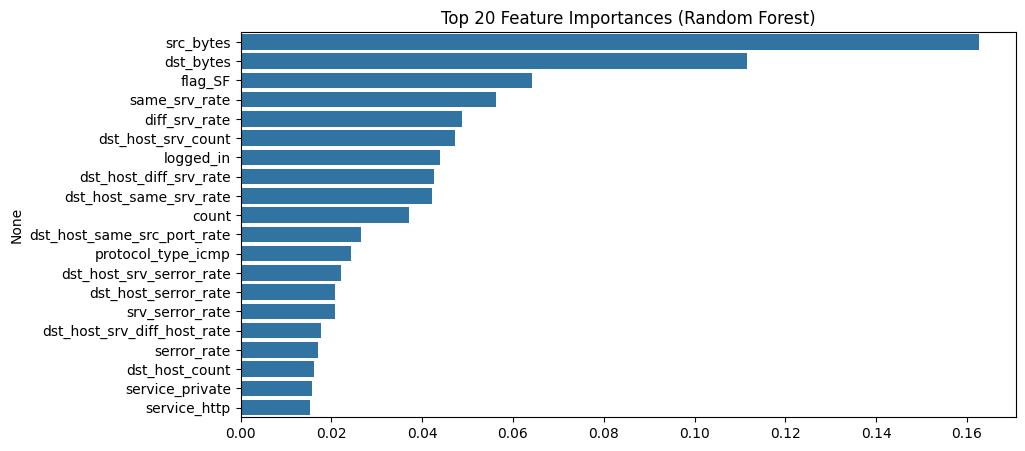

In [2]:
# NSL-KDD Intrusion Detection
# Random Forest + Logistic Regression + SMOTE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE


# Step 1: Load Dataset

columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
'is_host_login','is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty'
]

train_df = pd.read_csv("KDDTrain+.txt", names=columns)
test_df  = pd.read_csv("KDDTest+.txt", names=columns)


# Step 2: Preprocessing


train_df.drop('difficulty', axis=1, inplace=True)
test_df.drop('difficulty', axis=1, inplace=True)

# Binary classification
train_df['label'] = train_df['label'].apply(lambda x: 0 if x=='normal' else 1)
test_df['label']  = test_df['label'].apply(lambda x: 0 if x=='normal' else 1)

X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test  = test_df.drop('label', axis=1)
y_test  = test_df['label']

categorical_cols = ['protocol_type','service','flag']

# Reduce service cardinality
top_services = X_train['service'].value_counts().nlargest(20).index
X_train['service'] = X_train['service'].apply(lambda x: x if x in top_services else 'other')
X_test['service']  = X_test['service'].apply(lambda x: x if x in top_services else 'other')

# One-hot encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)



# Step 3: Apply SMOTE


smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_bal).value_counts())


# Step 4: Train Models


scaler = StandardScaler()

# Fit ONLY on training data
X_train_bal = scaler.fit_transform(X_train_bal)

# Apply SAME transformation to test data
X_test = scaler.transform(X_test)


# Random Forest
rf = RandomForestClassifier(
    n_estimators=1000,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_bal, y_train_bal)

# Logistic Regression
lr = LogisticRegression(
    max_iter=2000,
    solver='lbfgs'
)

lr.fit(X_train_bal, y_train_bal)


# Step 5: Predictions


# Training predictions
y_train_pred_rf = rf.predict(X_train_bal)
y_train_pred_lr = lr.predict(X_train_bal)

y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)


# Step 6: Evaluation


def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{name} Results:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return acc, prec, rec, f1

# Evaluate both models
rf_metrics = evaluate_model("Random Forest", y_test, y_pred_rf)
lr_metrics = evaluate_model("Logistic Regression", y_test, y_pred_lr)



# Step 7: Confusion Matrices (Train + Test)


fig, axes = plt.subplots(2, 2, figsize=(12,10))

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_train_bal, y_train_pred_rf, ax=axes[0,0]
)
axes[0,0].set_title("RF - Training")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=axes[0,1]
)
axes[0,1].set_title("RF - Testing")

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_train_bal, y_train_pred_lr, ax=axes[1,0]
)
axes[1,0].set_title("LR - Training")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[1,1]
)
axes[1,1].set_title("LR - Testing")

plt.tight_layout()
plt.show()


# Step 8: ROC Curves


rf_probs = rf.predict_proba(X_test)[:,1]
lr_probs = lr.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)

auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()

plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={auc_lr:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()


# Step 9: Feature Importance (RF only)


importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.show()


# Step 10: Performance Table


results_df = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [rf_metrics[0], lr_metrics[0]],
    "Precision": [rf_metrics[1], lr_metrics[1]],
    "Recall": [rf_metrics[2], lr_metrics[2]],
    "F1 Score": [rf_metrics[3], lr_metrics[3]]
}).round(4)

